(32, 320)
(32, 320)
0.4
0.1


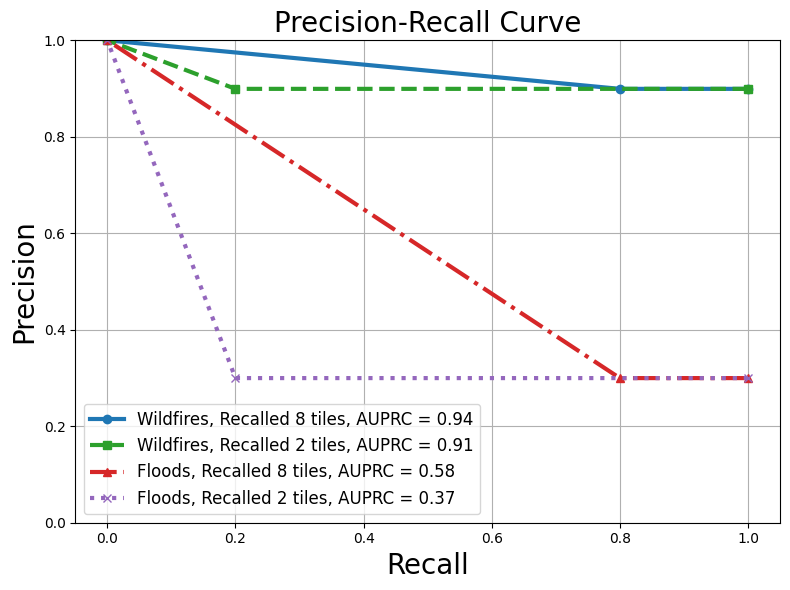

In [1]:
import numpy as np
from sklearn.metrics import precision_recall_curve, auc

# Define the shape of the array
shape = (32, 32)

# Calculate the total number of elements
total_elements = shape[0] * shape[1]

# Calculate the number of ones (approximately 30%)
num_ones_floods = int(total_elements * 0.3)
num_ones_fires = int(total_elements * 0.9)

# Create an array of zeros
flood_array = np.zeros(shape)
fire_array = np.zeros(shape)

# Generate random indices for ones
indices_floods = np.random.choice(total_elements, num_ones_floods, replace=False)
indices_fires = np.random.choice(total_elements, num_ones_fires, replace=False)


# Set ones at random indices
flood_array[np.unravel_index(indices_floods, shape)] = 1
fire_array[np.unravel_index(indices_fires, shape)] = 1
# Repeat the array horizontally 10 times
resulting_flood_array = np.tile(flood_array, (1, 10))
resulting_fire_array = np.tile(fire_array, (1, 10))

array_8_tiles = np.zeros((32, 32 * 10))
# Create an array with 8 tiles full of 0.5
array_8_tiles[:, : 32 * 8] = np.full((32, 32 * 8), 0.5)

# Create an array with 2 tiles full of 0.5 and the rest zeros
array_2_tiles = np.zeros((32, 32 * 10))
array_2_tiles[:, : 32 * 2] = np.full((32, 32 * 2), 0.5)

print(array_8_tiles.shape)
print(array_2_tiles.shape)
print(array_8_tiles.mean())
print(array_2_tiles.mean())
precision_8_floods, recall_8_floods, thresholds_8 = precision_recall_curve(
    resulting_flood_array.flatten(), array_8_tiles.flatten()
)
precision_2_floods, recall_2_floods, thresholds_2 = precision_recall_curve(
    resulting_flood_array.flatten(), array_2_tiles.flatten()
)
precision_8_fire, recall_8_fire, thresholds_8 = precision_recall_curve(
    resulting_fire_array.flatten(), array_8_tiles.flatten()
)
precision_2_fire, recall_2_fire, thresholds_2 = precision_recall_curve(
    resulting_fire_array.flatten(), array_2_tiles.flatten()
)

floods_2 = round(auc(recall_2_floods, precision_2_floods), 3)
floods_8 = round(auc(recall_8_floods, precision_8_floods), 3)
fire_2 = round(auc(recall_2_fire, precision_2_fire), 3)
fire_8 = round(auc(recall_8_fire, precision_8_fire), 3)
import matplotlib.pyplot as plt

# Define line styles and marker styles
line_styles = ["-", "--", "-.", ":"]
marker_styles = ["o", "s", "^", "x"]
colors = ["#1f77b4", "#2ca02c", "#d62728", "#9467bd"]  # Nicer colors

# Plot precision-recall curves
plt.figure(figsize=(8, 6))  # Adjust figure size for better visibility
for i, (label, recall, precision, auprc) in enumerate(
    zip(
        [
            "Wildfires, Recalled 8 tiles",
            "Wildfires, Recalled 2 tiles",
            "Floods, Recalled 8 tiles",
            "Floods, Recalled 2 tiles",
        ],
        [recall_8_fire, recall_2_fire, recall_8_floods, recall_2_floods],
        [precision_8_fire, precision_2_fire, precision_8_floods, precision_2_floods],
        [fire_8, fire_2, floods_8, floods_2],
    )
):
    plt.plot(
        recall,
        precision,
        linewidth=3,
        label=f"{label}, AUPRC = {auprc:.2f}",
        linestyle=line_styles[i % len(line_styles)],
        marker=marker_styles[i % len(marker_styles)],
        color=colors[i % len(colors)],
    )

plt.xlabel("Recall", fontsize=20)
plt.ylabel("Precision", fontsize=20)
plt.title("Precision-Recall Curve", fontsize=20)
plt.ylim(0, 1)  # Increase the font size of the legend

plt.legend(fontsize="large")
plt.grid(True)
plt.tight_layout()
plt.savefig("precision_recall_point.pdf", format="pdf", bbox_inches="tight")